<a href="https://colab.research.google.com/github/afraidspy/CienciaDatos/blob/main/DS_C3_SC2_Jessica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Análisis para abrir una sucursal de comida rápida en México

https://colab.research.google.com/drive/1BmsB-U1jHVr7J9wQRTGqfyHnjSULFehz?usp=sharing

### Jessica Santizo Galicia

In [20]:
import geopandas as gpd

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shapely.geometry import Point, LineString, Polygon

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Carga los datos de los Estados de la República Mexicana en un GeoDataFrame.






In [21]:
gdf = gpd.read_file('/content/drive/MyDrive/Colab Notebooks/files/mexican-states/mexican-states.shp')
gdf.head()


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:198: RuntimeWarning: /content/drive/MyDrive/Colab Notebooks/files/mexican-states/mexican-states.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


,ISO3166-2,admin_leve,boundary,is_in_coun,is_in_co_1,name,name_en,name_es,name_pl,name_ru,name_uk,place,ref,type,wikidata,wikipedia,geometry
0,MX-AGU,4,administrative,México,MX,Aguascalientes,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-102.7453 21.72005, -102.74859..."
1,MX-COL,4,administrative,México,MX,Colima,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-103.48859 18.96489, -103.4884..."
2,MX-TLA,4,administrative,México,MX,Tlaxcala,Tlaxcala,Tlaxcala,Tlaxcala,Тласкала,Тласкала,state,TLA,boundary,Q82681,es:Tlaxcala,"POLYGON ((-98.5415 19.46082, -98.54158 19.4607..."
3,MX-CMX,4,administrative,México,MX,Ciudad de México,Mexico City,Ciudad de México,None,None,None,state,DIF,boundary,Q1489,en:Mexico City,"POLYGON ((-99.2787 19.1317, -99.28259 19.13821..."
4,MX-MOR,4,administrative,México,MX,Morelos,Morelos,Morelos,Morelos,Морелос,Морелос,state,MOR,boundary,Q66117,es:Morelos,"POLYGON ((-98.90339 19.03848, -98.90061 19.038..."


In [22]:
#Conocer las columnas existentes y el tipo de dato de cada una de ellas

print(gdf.columns)
gdf.info()

Index(['ISO3166-2', 'admin_leve', 'boundary', 'is_in_coun', 'is_in_co_1',
       'name', 'name_en', 'name_es', 'name_pl', 'name_ru', 'name_uk', 'place',
       'ref', 'type', 'wikidata', 'wikipedia', 'geometry'],
      dtype='object')
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   ISO3166-2   32 non-null     object  
 1   admin_leve  32 non-null     object  
 2   boundary    32 non-null     object  
 3   is_in_coun  32 non-null     object  
 4   is_in_co_1  32 non-null     object  
 5   name        32 non-null     object  
 6   name_en     28 non-null     object  
 7   name_es     28 non-null     object  
 8   name_pl     27 non-null     object  
 9   name_ru     27 non-null     object  
 10  name_uk     27 non-null     object  
 11  place       28 non-null     object  
 12  ref         27 non-null     object  
 13  type        28 non-

<Axes: >

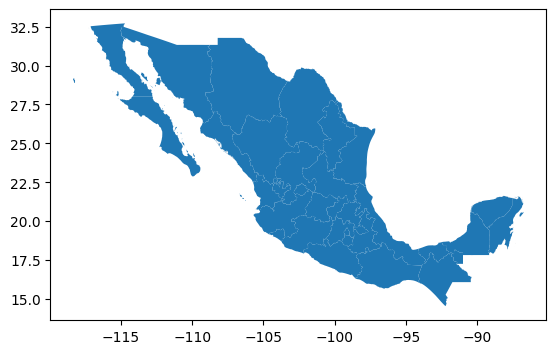

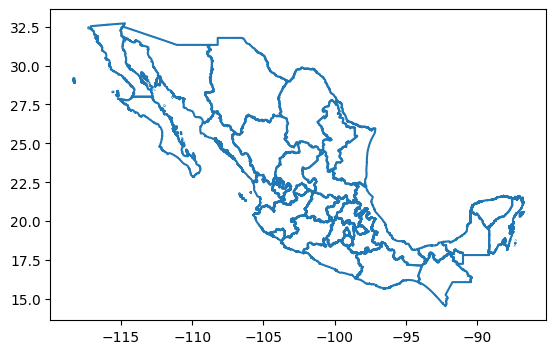

In [23]:
# Muestra el mapa, aquí dos formas de visualizar el mapa
gdf.plot()
gdf.boundary.plot()

3. Carga los datos de la localización de las sucursales de Costco® en un DataFrame.

In [24]:
# Visualizar las primeras 10 filas del documento
sucursales = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/files/tiendaCostco.csv')
sucursales.head(10)

,id,nombre,direccion,ubicacion,latitud,longitud,tel centro llantero
0,1,"""Puebla""",Blvd. del Niño Poblano 2904,Puebla,19.033499,-98.237794,222 2273 318
1,2,"""Villa Coapa""",Puente 186,Coapa,19.284359,-99.138655,NaN
2,3,"""Cuernavaca""",Av. Vicente Guerrero 205,Cuernavaca,18.934481,-99.233430,777 7101 523
3,4,"""Lindavista""",Av. Insurgentes Norte 1320,Gustavo A. Madero,19.481697,-99.130063,55 5747 5691
4,5,"""Mixcoac""",Blvd. Adolfo López Mateos 1181,Alvaro Obregón,19.387237,-99.190718,NaN
5,6,"""Polanco""",Blvd. Miguel de Cervantes Saavedra 397,Miguel Hidalgo,19.441589,-99.205685,55 2122 0262
6,7,"""Interlomas""",Blvd. Magnocentro 4,Huixquilucan,19.403408,-99.273534,NaN
7,8,"""Arboledas""",Av. San Nicolás 10,Tlalnepantla,19.551253,-99.202903,55 5321 3295
8,9,"""Satélite""",Circuito Centro Comercial 2001,Naucalpan,19.507850,-99.235338,NaN
9,10,"""Atizapán""","Av. Ruiz Cortines 1 Mz, 3 Lte 3",Atizapán de Zaragoza,19.548234,-99.270803,55 2345 0155


4. Convierte los datos de la localización de las sucursales de Costco® en un GeoDataFrame, creando puntos a partir de la longitud y latitud de cada sucursal

In [52]:
# Quitar espacios en lo nombres de las columnas
sucursales.columns = sucursales.columns.str.strip()

gdf_costco = gpd.GeoDataFrame(
    sucursales,
    geometry=gpd.points_from_xy(sucursales['longitud'], sucursales['latitud']),
    crs="EPSG:4326"
)
gdf_costco.head()

,id,nombre,direccion,ubicacion,latitud,longitud,tel centro llantero,geometry
0,1,"""Puebla""",Blvd. del Niño Poblano 2904,Puebla,19.033499,-98.237794,222 2273 318,POINT (-98.23779 19.0335)
1,2,"""Villa Coapa""",Puente 186,Coapa,19.284359,-99.138655,NaN,POINT (-99.13865 19.28436)
2,3,"""Cuernavaca""",Av. Vicente Guerrero 205,Cuernavaca,18.934481,-99.233430,777 7101 523,POINT (-99.23343 18.93448)
3,4,"""Lindavista""",Av. Insurgentes Norte 1320,Gustavo A. Madero,19.481697,-99.130063,55 5747 5691,POINT (-99.13006 19.4817)
4,5,"""Mixcoac""",Blvd. Adolfo López Mateos 1181,Alvaro Obregón,19.387237,-99.190718,NaN,POINT (-99.19072 19.38724)


5. Agrega una columna a los estados que indique la región a la que pertenecen y separa el GeoDataFrame por regiones en lugar de por estados

In [53]:
# Se obtienen los diferentes nombres de los lugares
gdf['name'].unique()

array(['Aguascalientes', 'Colima', 'Tlaxcala', 'Ciudad de México',
       'Morelos', 'México', 'Hidalgo', 'Puebla', 'Nuevo León',
       'Coahuila de Zaragoza', 'Chihuahua', 'Sonora',
       'Michoacán de Ocampo', 'Querétaro', 'Guanajuato', 'Jalisco',
       'Zacatecas', 'Durango', 'Tamaulipas',
       'Veracruz de Ignacio de la Llave', 'Guerrero', 'Sinaloa', 'Oaxaca',
       'Nayarit', 'Chiapas', 'Tabasco', 'Campeche', 'Baja California',
       'Baja California Sur', 'San Luis Potosí', 'Yucatán',
       'Quintana Roo'], dtype=object)

In [54]:

# Se crea un diccionario donde se clasifican los estados por región en el país.
regiones = {
    "Centro": [
        "Tlaxcala", "Puebla", "Ciudad de México", "Morelos", "México", "Hidalgo"
    ],
    "Centro Oeste": [
        "Jalisco", "Michoacán de Ocampo", "Colima", "Aguascalientes",
        "Nayarit", "Zacatecas", "San Luis Potosí", "Guanajuato", "Querétaro"
    ],
    "Noreste": [
        "Chihuahua", "Coahuila de Zaragoza", "Nuevo León", "Tamaulipas", "Durango"
    ],
    "Noroeste": [
        "Baja California", "Baja California Sur", "Sonora", "Sinaloa"
    ],
    "Sureste": [
        "Guerrero", "Veracruz de Ignacio de la Llave", "Oaxaca", "Tabasco",
        "Chiapas", "Campeche", "Yucatán", "Quintana Roo"
    ]
}

def asignar_region(nombre_estado):
    for region, estados in regiones.items():
        if nombre_estado in estados:
            return region
    return 'Sin region'

# Se agrega  la columna region al geo Data Frame de estados
gdf['region'] = gdf['name'].apply(asignar_region)


In [55]:
# Validar que se haya creado la columna region correctamente
gdf

,ISO3166-2,admin_leve,boundary,is_in_coun,is_in_co_1,name,name_en,name_es,name_pl,name_ru,name_uk,place,ref,type,wikidata,wikipedia,geometry,region
0,MX-AGU,4,administrative,México,MX,Aguascalientes,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-11437554.466 2462141.129, -11...",Centro Oeste
1,MX-COL,4,administrative,México,MX,Colima,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-11520297.62 2136923.091, -115...",Centro Oeste
2,MX-TLA,4,administrative,México,MX,Tlaxcala,Tlaxcala,Tlaxcala,Tlaxcala,Тласкала,Тласкала,state,TLA,boundary,Q82681,es:Tlaxcala,"POLYGON ((-10969589.491 2195037.196, -10969598...",Centro
3,MX-CMX,4,administrative,México,MX,Ciudad de México,Mexico City,Ciudad de México,None,None,None,state,DIF,boundary,Q1489,en:Mexico City,"POLYGON ((-11051653.796 2156450.689, -11052087...",Centro
4,MX-MOR,4,administrative,México,MX,Morelos,Morelos,Morelos,Morelos,Морелос,Морелос,state,MOR,boundary,Q66117,es:Morelos,"POLYGON ((-11009874.99 2145535.754, -11009565....",Centro
5,MX-MEX,4,administrative,México,MX,México,Mexico,México,Meksyk,Мехико,Мехіко,state,MEX,boundary,Q82112,es:Estado de México,"POLYGON ((-11147304.2 2263642.644, -11147265.3...",Centro
6,MX-HID,4,administrative,México,MX,Hidalgo,Hidalgo,Hidalgo,Hidalgo,Идальго,Ідальго,state,HID,boundary,Q80903,es:Estado de Hidalgo,"POLYGON ((-11102479.86 2325065.143, -11102477....",Centro
7,MX-PUE,4,administrative,México,MX,Puebla,Puebla,Puebla,Puebla,Пуэбла,Пуебла,state,PUE,boundary,Q79923,es:Puebla,"POLYGON ((-10827680.84 2185846.309, -10827544....",Centro
8,MX-NLE,4,administrative,México,MX,Nuevo León,Nuevo León,Nuevo León,Nuevo León,Нуэво-Леон,Нуево-Леон,state,NLE,boundary,Q15282,es:Nuevo León,"POLYGON ((-11126122.651 2675219.632, -11125950...",Noreste
9,MX-COA,4,administrative,México,MX,Coahuila de Zaragoza,Coahuila,Coahuila de Zaragoza,Coahuila,Коауила,Коауїла,state,COA,boundary,Q53079,es:Coahuila de Zaragoza,"POLYGON ((-11522563.072 2891691.409, -11522662...",Noreste


In [56]:
# Saber cuantos estados hay de cada reegion
gdf['region'].value_counts()

,count
region,
Centro Oeste,9
Sureste,8
Centro,6
Noreste,5
Noroeste,4


6. Asegura que ambos GeoDataFrames utilicen el CRS epsg=3395 que usa metros como medida de distancia.

In [57]:
# Reproyectar ambos GeoDataFrames a EPSG:3395 (metros)
gdf = gdf.to_crs(epsg=3395)
gdf_costco = gdf_costco.to_crs(epsg=3395)

# Verificar CRS de ambos
gdf.crs, gdf_costco.crs


(<Projected CRS: EPSG:3395>
 Name: WGS 84 / World Mercator
 Axis Info [cartesian]:
 - E[east]: Easting (metre)
 - N[north]: Northing (metre)
 Area of Use:
 - name: World between 80°S and 84°N.
 - bounds: (-180.0, -80.0, 180.0, 84.0)
 Coordinate Operation:
 - name: World Mercator
 - method: Mercator (variant A)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 <Projected CRS: EPSG:3395>
 Name: WGS 84 / World Mercator
 Axis Info [cartesian]:
 - E[east]: Easting (metre)
 - N[north]: Northing (metre)
 Area of Use:
 - name: World between 80°S and 84°N.
 - bounds: (-180.0, -80.0, 180.0, 84.0)
 Coordinate Operation:
 - name: World Mercator
 - method: Mercator (variant A)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

7. Crea un buffer de 120 km alrededor de los puntos de localización de cada sucursal.

In [58]:
buffer_costco = gdf_costco.copy()
buffer_costco['geometry'] = buffer_costco.buffer(120000)

# Mostrar los primeros buffers creados
buffer_costco.head()

,id,nombre,direccion,ubicacion,latitud,longitud,tel centro llantero,geometry
0,1,"""Puebla""",Blvd. del Niño Poblano 2904,Puebla,19.033499,-98.237794,222 2273 318,"POLYGON ((-10815781.179 2144952.355, -10816359..."
1,2,"""Villa Coapa""",Puente 186,Coapa,19.284359,-99.138655,NaN,"POLYGON ((-10916064.551 2174338.736, -10916642..."
2,3,"""Cuernavaca""",Av. Vicente Guerrero 205,Cuernavaca,18.934481,-99.233430,777 7101 523,"POLYGON ((-10926614.869 2133365.534, -10927192..."
3,4,"""Lindavista""",Av. Insurgentes Norte 1320,Gustavo A. Madero,19.481697,-99.130063,55 5747 5691,"POLYGON ((-10915108.091 2197487.393, -10915685..."
4,5,"""Mixcoac""",Blvd. Adolfo López Mateos 1181,Alvaro Obregón,19.387237,-99.190718,NaN,"POLYGON ((-10921860.248 2186403.224, -10922438..."



8. Grafica la intersección de las regiones con los círculos creados a partir de la localización de las sucursales.



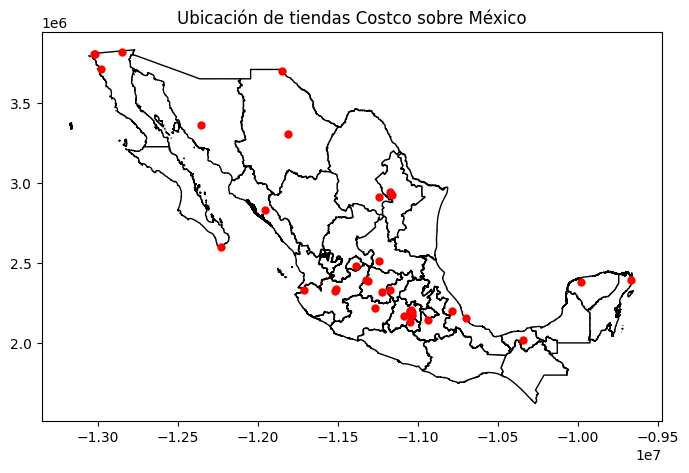

In [61]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(ax=ax, color='white', edgecolor='black')
gdf_costco.plot(ax=ax, color='red', markersize=25)
plt.title("Ubicación de tiendas Costco sobre México")
plt.show()


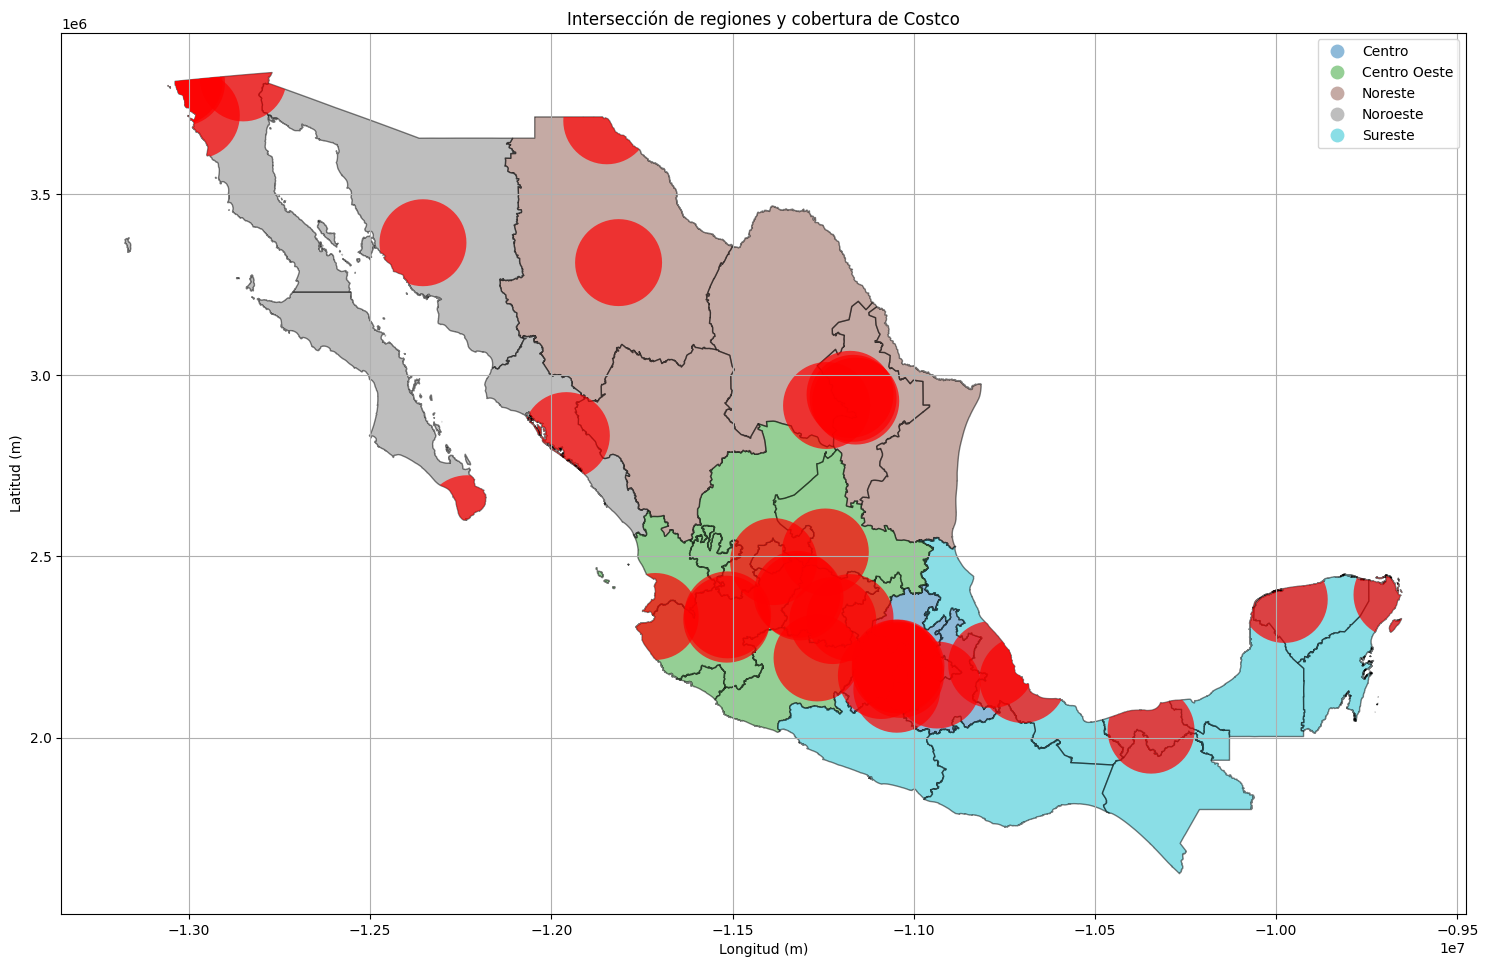

In [64]:
# Intersecction
inter = gpd.overlay(gdf, buffer_costco, how='intersection')

# Plot
fig, ax = plt.subplots(figsize=(15, 15))
gdf.plot(ax=ax, column="region", legend=True, alpha=0.5, edgecolor='black')
inter.plot(ax=ax, color='red', alpha=0.7)


plt.title("Intersección de regiones y cobertura de Costco")
plt.xlabel("Longitud(m)")
plt.ylabel("Latitud(m)")
plt.grid(True)
plt.tight_layout()
plt.show()


9. Identifica las regiones en donde se requiere más cobertura e indica en qué regiones del país NO es conveniente abrir una nueva sucursal debido a la falta de cobertura de entregas a domicilio.


In [65]:

# 1. Unión de todos los buffers
buffer_union = buffer_costco.union_all()

# 2. Disolver estados por región
regiones_gdf = gdf.dissolve(by="region")

# 3. Calcular cobertura por región
regiones_gdf["area_total"] = regiones_gdf.area
regiones_gdf["area_cubierta"] = regiones_gdf.intersection(buffer_union).area
regiones_gdf["porcentaje_cubierto"] = (regiones_gdf["area_cubierta"] / regiones_gdf["area_total"]) * 100

# 4. Clasificar si requiere más cobertura
def evaluar_region(p):
    if p < 30:
        return "Alta necesidad de cobertura"
    elif p < 70:
        return "Cobertura media"
    else:
        return "Buena cobertura"

regiones_gdf["evaluacion"] = regiones_gdf["porcentaje_cubierto"].apply(evaluar_region)

# Mostrar resultados
print(regiones_gdf[["porcentaje_cubierto", "evaluacion"]])


              porcentaje_cubierto                   evaluacion
region                                                        
Centro                  81.269169              Buena cobertura
Centro Oeste            53.304320              Cobertura media
Noreste                 16.372330  Alta necesidad de cobertura
Noroeste                22.995552  Alta necesidad de cobertura
Sureste                 22.936762  Alta necesidad de cobertura


El resultado anterior muestra que la región Centro del país cuenta con una buena cobertura (81%), por lo que no es conveniente abrir nuevas sucursales allí debido a la alta concentración de puntos de venta y competencia. La región Centro Oeste presenta una cobertura media (53%), lo que sugiere potencial para una expansión selectiva en zonas con menor presencia. En contraste, las **regiones Noreste (16%), Noroeste (23%) y Sureste (23%) presentan una alta necesidad de cobertura.**